In [ ]:
# pip install nibabel matplotlib scikit-learn scikit-image tensorflow
# GPU on Windows: TF 2.11+ needs WSL2 + Ubuntu, then in WSL: pip install 'tensorflow[and-cuda]'
# (Native Windows pip tensorflow is usually CPU-only for current TF versions.)

  Using cached tensorflow-2.21.0-cp311-cp311-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached requests-2.33.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached wrapt-2.1.2-cp311-cp311-win_amd64.whl.metadata (7.6 kB)
  Using cached grpcio-1.80.0-cp311-cp311-win_amd64.whl.metadata (3.9 kB)
  Using cached keras-3.14.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached h5py-3

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import os
import glob
import numpy as np
import nibabel as nib
from pathlib import Path
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)

In [2]:
# Load one CT volume (build path safely on Windows)
ct_path = Path("Data") / "Training" / "dataset-verse19training" / "rawdata" / "sub-verse004" / "sub-verse004_ct.nii.gz"
print("CT path:", ct_path.resolve())

if not ct_path.exists():
    raise FileNotFoundError(f"CT file not found at: {ct_path.resolve()}")

img = nib.load(str(ct_path))
data = img.get_fdata()
print(f"Shape: {data.shape}")  # Likely (depth, height, width)
print(f"Data range: {data.min()} to {data.max()}")

CT path: D:\UNI\Year 4\Spring\Deep Learning 🧠\Assignment 2\Data\Training\dataset-verse19training\rawdata\sub-verse004\sub-verse004_ct.nii.gz
Shape: (161, 338, 61)
Data range: -1304.8939208984375 to 2906.17138671875


In [3]:
# Parameters
IMG_SIZE = 128  # Target size (128x128)
SLICES_PER_VOLUME = 60  # Keep fewer, more informative slices
WINDOW_CENTER = 100  # CT window (tweak if needed)
WINDOW_WIDTH = 350  # Width in Hounsfield Units

# Slice selection behavior
SLICE_SELECTION = "topk_std"  # "topk_std" | "topk_fg" | "middle"

In [4]:
def normalize_ct_volume(volume, center, width):
    """
    Apply Hounsfield windowing and normalize to [0,1]
    """

    # Clip to window range
    min_hu = center - width // 2
    max_hu = center + width // 2
    volume_clipped = np.clip(volume, min_hu, max_hu)

    # Normalize to [0,1]
    volume_norm = (volume_clipped - min_hu) / (max_hu - min_hu)

    return volume_norm

In [5]:
def extract_2d_slices(
    volume,
    num_slices=60,
    target_size=(128, 128),
    slice_axis=None,
    selection="topk_std",
):
    """Extract informative 2D slices and resize.

    - By default, we slice along the smallest volume dimension (often the axial depth).
    - selection:
        - "middle": take middle num_slices
        - "topk_std": take top-k slices by per-slice standard deviation (more structure)
        - "topk_fg": take top-k slices by foreground fraction (pixels > threshold)
    """
    from skimage.transform import resize

    vol = np.asarray(volume)

    if slice_axis is None:
        slice_axis = int(np.argmin(vol.shape))

    depth = vol.shape[slice_axis]
    if num_slices > depth:
        num_slices = depth

    # Pull all slices along the chosen axis
    slices_2d = [np.take(vol, i, axis=slice_axis) for i in range(depth)]

    if selection == "middle":
        start = (depth - num_slices) // 2
        idxs = list(range(start, start + num_slices))

    elif selection == "topk_std":
        scores = np.array([np.std(s) for s in slices_2d], dtype=np.float32)
        idxs = np.argsort(scores)[-num_slices:]
        idxs = np.sort(idxs)

    elif selection == "topk_fg":
        # Works on normalized [0,1] volumes; tweak threshold if needed
        thr = 0.55
        scores = np.array([(s > thr).mean() for s in slices_2d], dtype=np.float32)
        idxs = np.argsort(scores)[-num_slices:]
        idxs = np.sort(idxs)

    else:
        raise ValueError(f"Unknown selection: {selection}")

    out = []
    for i in idxs:
        s = slices_2d[int(i)]
        s_resized = resize(s, target_size, preserve_range=True, anti_aliasing=True)
        out.append(s_resized)

    return np.asarray(out, dtype=np.float32)

In [7]:
def collect_slices_from_rawdata(rawdata_dir: Path) -> np.ndarray:
    rawdata_dir = rawdata_dir.resolve()
    print("Rawdata dir:", rawdata_dir)

    if not rawdata_dir.exists():
        raise FileNotFoundError(f"Rawdata directory not found at: {rawdata_dir}")

    subject_folders = sorted(glob.glob(str(rawdata_dir / "sub-verse*")))
    print(f"Found {len(subject_folders)} subjects")

    all_slices = []

    for folder in subject_folders:
            # Prefer CT file patterns; accept .nii and .nii.gz
        ct_candidates = (
            glob.glob(os.path.join(folder, "*_ct.nii.gz"))
            + glob.glob(os.path.join(folder, "*_ct.nii"))
            + glob.glob(os.path.join(folder, "*.nii.gz"))
            + glob.glob(os.path.join(folder, "*.nii"))
        )

        if not ct_candidates:
            print(f"Skipping (no NIfTI found): {os.path.basename(folder)}")
            continue

        nii_path = ct_candidates[0]
        print(f"Loading: {os.path.basename(folder)} -> {os.path.basename(nii_path)}")

        img = nib.load(nii_path)
        volume = img.get_fdata()

        volume_norm = normalize_ct_volume(volume, WINDOW_CENTER, WINDOW_WIDTH)

        slices = extract_2d_slices(
            volume_norm,
            num_slices=SLICES_PER_VOLUME,
            target_size=(IMG_SIZE, IMG_SIZE),
            selection=SLICE_SELECTION,
        )

        all_slices.extend(slices)

    X = np.asarray(all_slices, dtype=np.float32)
    print(f"Total slices collected: {len(all_slices)}")
    return X


    # Official dataset split roots
    train_raw = Path("Data") / "Training" / "dataset-verse19training" / "rawdata"
    val_raw = Path("Data") / "Validation" / "dataset-verse19validation" / "rawdata"
    test_raw = Path("Data") / "Test" / "dataset-verse19test" / "rawdata"

    # Load each split separately (do NOT mix these)
    X_train = collect_slices_from_rawdata(train_raw)
    X_val = collect_slices_from_rawdata(val_raw)
    X_test = collect_slices_from_rawdata(test_raw)

Rawdata dir: D:\UNI\Year 4\Spring\Deep Learning 🧠\Assignment 2\Data\Training\dataset-verse19training\rawdata
Found 67 subjects
Loading: sub-verse004 -> sub-verse004_ct.nii.gz
Loading: sub-verse005 -> sub-verse005_ct.nii.gz
Loading: sub-verse006 -> sub-verse006_ct.nii.gz
Loading: sub-verse007 -> sub-verse007_ct.nii.gz
Loading: sub-verse008 -> sub-verse008_ct.nii.gz
Loading: sub-verse009 -> sub-verse009_ct.nii.gz
Loading: sub-verse014 -> sub-verse014_ct.nii.gz
Loading: sub-verse015 -> sub-verse015_ct.nii.gz
Loading: sub-verse031 -> sub-verse031_ct.nii.gz
Loading: sub-verse033 -> sub-verse033_ct.nii.gz
Loading: sub-verse034 -> sub-verse034_ct.nii.gz
Loading: sub-verse036 -> sub-verse036_ct.nii.gz
Loading: sub-verse043 -> sub-verse043_ct.nii.gz
Loading: sub-verse046 -> sub-verse046_ct.nii.gz
Loading: sub-verse048 -> sub-verse048_ct.nii.gz
Loading: sub-verse051 -> sub-verse051_ct.nii.gz
Loading: sub-verse056 -> sub-verse056_ct.nii.gz
Loading: sub-verse060 -> sub-verse060_ct.nii.gz
Loading: 

In [17]:
def summarize_split(name: str, X: np.ndarray):
    print(f"{name}: shape={X.shape}, dtype={X.dtype}, range=({X.min():.3f}, {X.max():.3f})")

summarize_split("Train", X_train)
summarize_split("Val", X_val)
summarize_split("Test", X_test)

Train: shape=(3904, 128, 128), dtype=float32, range=(0.000, 1.000)
Val: shape=(2144, 128, 128), dtype=float32, range=(0.000, 1.000)
Test: shape=(2066, 128, 128), dtype=float32, range=(0.000, 1.000)


In [18]:
# Optional disk cache — does NOT touch collect_slices_from_rawdata.
# After the long load finishes once, run save_slice_arrays() here to write slice_arrays_cache.npz.
# Next session: run imports + helpers (cells 1,3–5), skip the long load cell, then uncomment:
# load_slice_arrays()
# …then run the rest of the notebook.

SLICE_ARRAYS_CACHE = Path("slice_arrays_cache.npz")


def save_slice_arrays(path: Path = SLICE_ARRAYS_CACHE) -> None:
    np.savez_compressed(path, X_train=X_train, X_val=X_val, X_test=X_test)
    print("Saved:", path.resolve())


def load_slice_arrays(path: Path = SLICE_ARRAYS_CACHE) -> bool:
    """Load X_train/X_val/X_test from cache. Returns True if loaded."""
    if not path.exists():
        print("No cache at:", path.resolve())
        return False
    z = np.load(path)
    globals()["X_train"] = z["X_train"]
    globals()["X_val"] = z["X_val"]
    globals()["X_test"] = z["X_test"]
    print("Loaded from:", path.resolve())
    return True


def _squeeze_to_2d(X: np.ndarray) -> np.ndarray:
    X = np.asarray(X)
    if X.ndim == 4 and X.shape[-1] == 1:
        return X[..., 0]
    return X


def _slice_informativeness(s: np.ndarray, fg_thr: float) -> float:
    fg = float(np.mean(s > fg_thr))
    return float(np.std(s) * (0.25 + fg))


def sample_slice_indices_for_plot(
    X: np.ndarray,
    n: int = 10,
    seed: int = 42,
    fg_thr: float = 0.12,
    one_per_volume: bool = True,
    pool: int = 2500,
) -> np.ndarray:
    """Pick indices from existing X (no NIfTI reload).

    Default ``one_per_volume=True``: picks one best slice from each of ``n``
    different volume-blocks (uses global SLICES_PER_VOLUME if set). This avoids
    the old behavior where top-k scores were often *adjacent* slices from the
    same scan (nearly identical thumbnails).

    Set ``one_per_volume=False`` to use a random pool + greedy spacing instead.
    """
    X2 = _squeeze_to_2d(X)
    rng = np.random.default_rng(seed)
    n_total = len(X2)
    chunk = int(globals().get("SLICES_PER_VOLUME", 60))
    chunk = max(1, chunk)

    if one_per_volume:
        n_vol = max(1, (n_total + chunk - 1) // chunk)
        n_pick = min(n, n_vol)
        vol_ids = rng.choice(n_vol, size=n_pick, replace=False)
        picked = []
        for v in vol_ids:
            lo = int(v) * chunk
            hi = min(lo + chunk, n_total)
            if lo >= hi:
                continue
            best_i = max(range(lo, hi), key=lambda i: _slice_informativeness(X2[i], fg_thr))
            picked.append(best_i)
        return np.sort(np.array(picked, dtype=np.int64))

    pool = min(pool, n_total)
    cand = rng.choice(n_total, size=pool, replace=False)
    scores = np.array([_slice_informativeness(X2[int(i)], fg_thr) for i in cand])
    order = cand[np.argsort(-scores)]
    min_gap = max(8, chunk // 4)
    chosen = []
    for idx in order:
        idx = int(idx)
        if all(abs(idx - c) >= min_gap for c in chosen):
            chosen.append(idx)
        if len(chosen) >= n:
            break
    if len(chosen) < n:
        for idx in order:
            idx = int(idx)
            if idx not in chosen:
                chosen.append(idx)
            if len(chosen) >= n:
                break
    return np.sort(np.array(chosen[:n], dtype=np.int64))


# Indices for plotting: one informative slice per volume (diverse grid)
PLOT_INDICES = sample_slice_indices_for_plot(X_train, n=10, seed=42, one_per_volume=True)

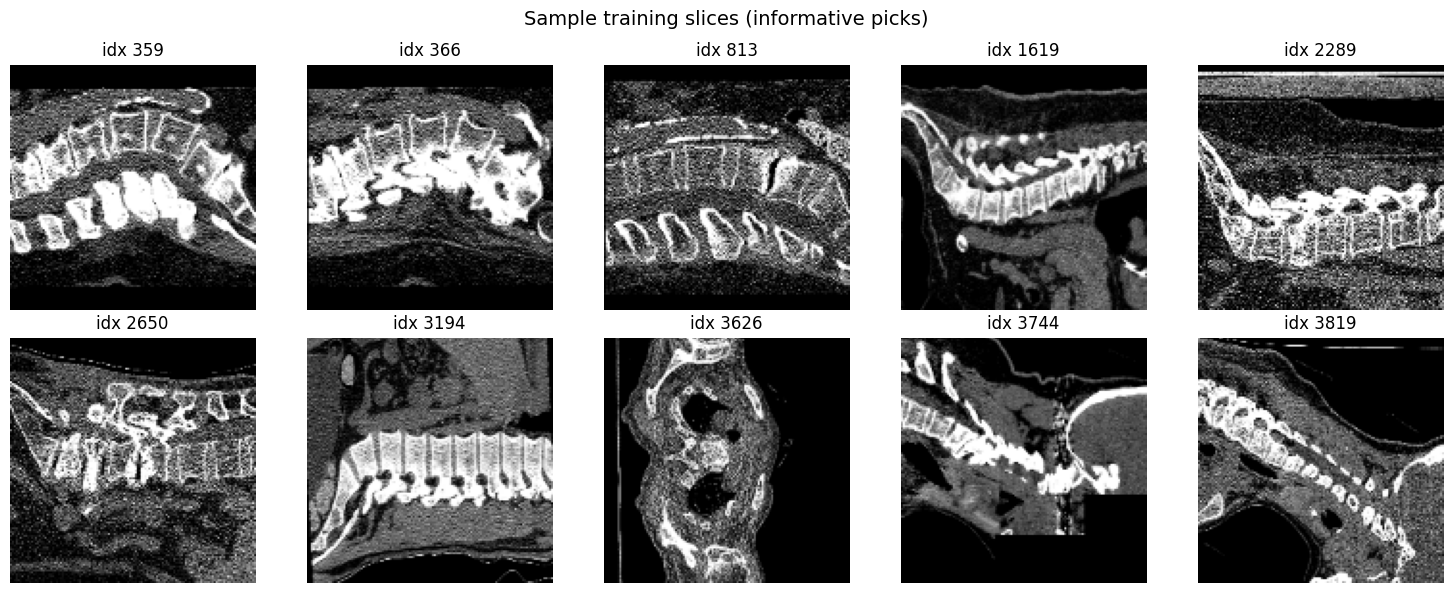

In [15]:
# Display sample slices (uses PLOT_INDICES from previous cell — no re-collection)
X_plot = _squeeze_to_2d(X_train)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, idx in zip(axes.flat, PLOT_INDICES):
    ax.imshow(X_plot[int(idx)], cmap='gray', vmin=0.0, vmax=1.0)
    ax.set_title(f"idx {int(idx)}")
    ax.axis('off')
plt.suptitle("Sample training slices (informative picks)", fontsize=14)
plt.tight_layout()
plt.show()

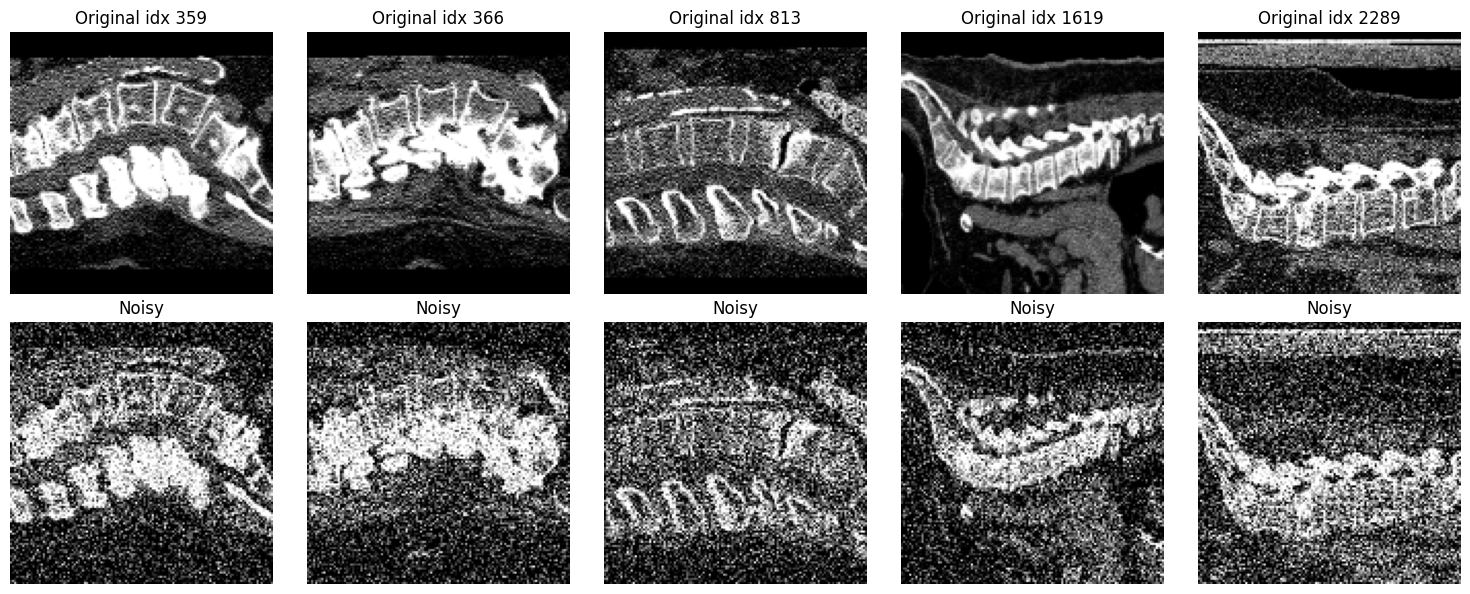

In [19]:
# Create noisy version of training set for denoising task
def add_gaussian_noise(images, noise_factor=0.3):
    noisy = images + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    return np.clip(noisy, 0.0, 1.0)


# Create noisy training set
X_train_noisy = add_gaussian_noise(X_train)

# Visualize original vs noisy (same informative indices as grid above)
X_plot = _squeeze_to_2d(X_train)
N_show = min(5, len(PLOT_INDICES))
idxs = PLOT_INDICES[:N_show]
X_noisy_plot = _squeeze_to_2d(X_train_noisy)

fig, axes = plt.subplots(2, N_show, figsize=(3 * N_show, 6))
for i, idx in enumerate(idxs):
    idx = int(idx)
    axes[0, i].imshow(X_plot[idx], cmap='gray', vmin=0.0, vmax=1.0)
    axes[0, i].set_title(f"Original idx {idx}")
    axes[0, i].axis('off')

    axes[1, i].imshow(X_noisy_plot[idx], cmap='gray', vmin=0.0, vmax=1.0)
    axes[1, i].set_title("Noisy")
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

In [20]:
# Add channel dimension (grayscale = 1 channel)
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]
X_train_noisy = X_train_noisy[..., np.newaxis]

print(f"Final shapes with channel: {X_train.shape}")

Final shapes with channel: (3904, 128, 128, 1)


In [22]:
import sys
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

# --- GPU (TensorFlow sees a GPU only if the install + OS stack supports it) ---
print("TensorFlow:", tf.__version__, "| Python:", sys.version.split()[0], "| OS:", sys.platform)
gpus = tf.config.list_physical_devices("GPU")
print("Num GPUs visible to TensorFlow:", len(gpus))
for gpu in gpus:
    print(" ", gpu)
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

if not gpus:
    print("\nNo GPU detected — training will use CPU.")
    if sys.platform == "win32":
        print(
            "On native Windows, official TensorFlow builds only support GPU up to TF 2.10.\n"
            "From TF 2.11 onward, use one of:\n"
            "  A) WSL2 (Ubuntu) + NVIDIA driver on Windows + in WSL: pip install -U pip && pip install 'tensorflow[and-cuda]'\n"
            "  B) Google Colab / another Linux GPU machine\n"
            "  C) Stay on CPU, or try tensorflow-directml (different stack; see Microsoft docs)\n"
            "Also run: nvidia-smi  (should list your GPU if the driver is OK)."
        )
    else:
        print("Linux: pip install 'tensorflow[and-cuda]' (needs NVIDIA driver). Or use Colab.")

# Input shape
input_shape = (128, 128, 1)

# Encoder
input_img = layers.Input(shape=input_shape)
x = layers.Flatten()(input_img)
x = layers.Dense(1024, activation='relu')(x)
x = layers.Dense(512, activation='relu')(x)
bottleneck = layers.Dense(128, activation='relu', name='bottleneck')(x)  # Latent space

# Decoder
x = layers.Dense(512, activation='relu')(bottleneck)
x = layers.Dense(1024, activation='relu')(x)
x = layers.Dense(128 * 128, activation='sigmoid')(x)
output_img = layers.Reshape(input_shape)(x)

# Model
basic_ae = Model(input_img, output_img, name='basic_ae')
basic_ae.compile(optimizer='adam', loss='mse')
basic_ae.summary()

Num GPUs available: 0
Training will run on CPU. Install tensorflow with GPU support and CUDA/cuDNN, or use a GPU runtime (e.g. Colab).


Model: "basic_ae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1024)           │    16,778,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 16384)          │    16,793,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 128, 128, 1)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,753,664 (132.57 MB)

 Trainable params: 34,753,664 (132.57 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# Denoising AE: map noisy input -> clean target (val: noisy val input vs clean val target)
# Build val noisy tensors to match X_val (same noise settings as training)
rng = np.random.default_rng(42)
val_noise = 0.3 * rng.standard_normal(size=X_val.shape, dtype=np.float32)
X_val_noisy = np.clip(X_val.astype(np.float32) + val_noise, 0.0, 1.0)

history_basic = basic_ae.fit(
    X_train_noisy,
    X_train,
    epochs=30,
    batch_size=128,
    validation_data=(X_val_noisy, X_val),
    shuffle=True,
    verbose=1,
)

Epoch 1/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 27s 856ms/step - loss: 0.0586 - val_loss: 0.0623
Epoch 2/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 24s 769ms/step - loss: 0.0526 - val_loss: 0.0589
Epoch 3/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 21s 682ms/step - loss: 0.0455 - val_loss: 0.0556
Epoch 4/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 20s 626ms/step - loss: 0.0413 - val_loss: 0.0538
Epoch 5/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 19s 604ms/step - loss: 0.0385 - val_loss: 0.0530
Epoch 6/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 19s 614ms/step - loss: 0.0355 - val_loss: 0.0537
Epoch 7/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 20s 660ms/step - loss: 0.0330 - val_loss: 0.0531
Epoch 8/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 19s 619ms/step - loss: 0.0305 - val_loss: 0.0518
Epoch 9/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 20s 629ms/step - loss: 0.0283 - val_loss: 0.0527
Epoch 10/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 19s 620ms/step - loss: 0.0263 - val_loss: 0.0517
Epoch 11/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 20s 605ms/step - loss: 0.0248 - val_loss: 0.0520
Epoch 12/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 20

In [ ]:
# Plot loss curve
plt.figure(figsize=(10, 4))
plt.plot(history_basic.history['loss'], label='Training Loss')
plt.plot(history_basic.history['val_loss'], label='Validation Loss')
plt.title('Basic Autoencoder - Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
class ConvAutoencoder(Model):
    """Convolutional autoencoder for image reconstruction"""
    def __init__(self, latent_dim=256):
        super(ConvAutoencoder, self).__init__()
        self.latent_dim = latent_dim
        
        # Encoder
        self.encoder = keras.Sequential([
            layers.Input(shape=(128, 128, 1)),
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.MaxPooling2D((2, 2), padding='same'),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
            layers.MaxPooling2D((2, 2), padding='same'),
            layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
            layers.MaxPooling2D((2, 2), padding='same'),
            layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
            layers.MaxPooling2D((2, 2), padding='same'),
            layers.Flatten(),
            layers.Dense(latent_dim, activation='relu', name='bottleneck')
        ])
        
        # Decoder
        self.decoder = keras.Sequential([
            layers.Dense(8 * 8 * 256, activation='relu'),
            layers.Reshape((8, 8, 256)),
            layers.Conv2DTranspose(128, (3, 3), activation='relu', padding='same'),
            layers.UpSampling2D((2, 2)),
            layers.Conv2DTranspose(64, (3, 3), activation='relu', padding='same'),
            layers.UpSampling2D((2, 2)),
            layers.Conv2DTranspose(32, (3, 3), activation='relu', padding='same'),
            layers.UpSampling2D((2, 2)),
            layers.Conv2DTranspose(16, (3, 3), activation='relu', padding='same'),
            layers.UpSampling2D((2, 2)),
            layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')
        ])
    
    def call(self, x):
        if len(x.shape) == 3:
            x = tf.expand_dims(x, axis=-1)
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return tf.squeeze(decoded, axis=-1)
    
    def get_bottleneck(self, x):
        if len(x.shape) == 3:
            x = tf.expand_dims(x, axis=-1)
        return self.encoder(x)

# Prepare data with channel dimension
X_train_conv = tf.expand_dims(X_train, axis=-1)
X_val_conv = tf.expand_dims(X_val, axis=-1)
X_test_conv = tf.expand_dims(X_test, axis=-1)

# Build and compile
conv_ae = ConvAutoencoder(latent_dim=256)
conv_ae.compile(optimizer='adam', loss='mse')
conv_ae.build(input_shape=(None, 128, 128, 1))
conv_ae.summary()

In [ ]:
# Train Convolutional Autoencoder
history_conv = conv_ae.fit(
    X_train_conv, X_train,
    epochs=40,
    batch_size=32,
    validation_data=(X_val_conv, X_val),
    shuffle=True,
    verbose=1
)

# Plot loss curve
plt.figure(figsize=(10, 4))
plt.plot(history_conv.history['loss'], label='Training Loss')
plt.plot(history_conv.history['val_loss'], label='Validation Loss')
plt.title('Convolutional Autoencoder - Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def add_gaussian_noise(images, noise_factor=0.3):
    """Add Gaussian noise to images"""
    noisy_images = images + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    return np.clip(noisy_images, 0.0, 1.0)

def add_salt_pepper_noise(images, prob=0.05):
    """Add salt and pepper noise to images"""
    noisy = images.copy()
    for i in range(len(images)):
        mask = np.random.random(images[i].shape) < prob
        noisy[i][mask] = np.random.choice([0, 1], size=mask.sum())
    return noisy

# Create noisy training data
X_train_noisy = add_gaussian_noise(X_train, noise_factor=0.3)
X_val_noisy = add_gaussian_noise(X_val, noise_factor=0.3)
X_test_noisy = add_gaussian_noise(X_test, noise_factor=0.3)

# Visualize noisy images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    idx = PLOT_INDICES[i % len(PLOT_INDICES)]
    ax.imshow(X_train_noisy[idx], cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'Noisy {idx}')
    ax.axis('off')
plt.suptitle('Noisy Training Images (Gaussian Noise)', fontsize=14)
plt.tight_layout()
plt.show()

In [27]:
class DenoisingAutoencoder(Model):
    """Denoising autoencoder - learns to reconstruct clean images from noisy inputs"""
    def __init__(self, latent_dim=128):
        super(DenoisingAutoencoder, self).__init__()
        self.latent_dim = latent_dim
        
        # Encoder
        self.encoder = keras.Sequential([
            layers.Input(shape=(128, 128, 1)),
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.MaxPooling2D((2, 2), padding='same'),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
            layers.MaxPooling2D((2, 2), padding='same'),
            layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
            layers.MaxPooling2D((2, 2), padding='same'),
            layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
            layers.MaxPooling2D((2, 2), padding='same'),
            layers.Flatten(),
            layers.Dense(latent_dim, activation='relu', name='bottleneck')
        ])
        
        # Decoder
        self.decoder = keras.Sequential([
            layers.Dense(8 * 8 * 256, activation='relu'),
            layers.Reshape((8, 8, 256)),
            layers.Conv2DTranspose(128, (3, 3), activation='relu', padding='same'),
            layers.UpSampling2D((2, 2)),
            layers.Conv2DTranspose(64, (3, 3), activation='relu', padding='same'),
            layers.UpSampling2D((2, 2)),
            layers.Conv2DTranspose(32, (3, 3), activation='relu', padding='same'),
            layers.UpSampling2D((2, 2)),
            layers.Conv2DTranspose(16, (3, 3), activation='relu', padding='same'),
            layers.UpSampling2D((2, 2)),
            layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')
        ])
    
    def call(self, x):
        if len(x.shape) == 3:
            x = tf.expand_dims(x, axis=-1)
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return tf.squeeze(decoded, axis=-1)

# Build and compile denoising autoencoder
denoising_ae = DenoisingAutoencoder(latent_dim=128)
denoising_ae.compile(optimizer='adam', loss='mse')
denoising_ae.build(input_shape=(None, 128, 128, 1))
denoising_ae.summary()

c:\Users\Abd Elrahman\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\layer.py:427: UserWarning: `build()` was called on layer 'denoising_autoencoder_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "denoising_autoencoder_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 128)            │     2,485,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,485,120 (9.48 MB)

 Trainable params: 2,485,120 (9.48 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# Train Denoising Autoencoder
history_denoise = denoising_ae.fit(
    X_train_noisy, X_train,
    epochs=40,
    batch_size=32,
    validation_data=(X_val_noisy, X_val),
    shuffle=True,
    verbose=1
)

# Plot loss curve
plt.figure(figsize=(10, 4))
plt.plot(history_denoise.history['loss'], label='Training Loss')
plt.plot(history_denoise.history['val_loss'], label='Validation Loss')
plt.title('Denoising Autoencoder - Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

Epoch 1/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 85s 653ms/step - loss: 0.0546 - val_loss: 0.0431
Epoch 2/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 80s 656ms/step - loss: 0.0357 - val_loss: 0.0395
Epoch 3/40
 52/122 ━━━━━━━━━━━━━━━━━━━━ 35s 501ms/step - loss: 0.0311

KeyboardInterrupt: 

In [ ]:
class VAE(Model):
    """Variational Autoencoder with sampling layer"""
    def __init__(self, latent_dim=64):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim
        
        # Encoder
        self.encoder = keras.Sequential([
            layers.Input(shape=(128, 128, 1)),
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.MaxPooling2D((2, 2), padding='same'),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
            layers.MaxPooling2D((2, 2), padding='same'),
            layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
            layers.MaxPooling2D((2, 2), padding='same'),
            layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
            layers.MaxPooling2D((2, 2), padding='same'),
            layers.Flatten(),
        ])
        
        # Latent space parameters
        self.dense_mean = layers.Dense(latent_dim, name='z_mean')
        self.dense_log_var = layers.Dense(latent_dim, name='z_log_var')
        
        # Decoder
        self.decoder = keras.Sequential([
            layers.Dense(8 * 8 * 256, activation='relu'),
            layers.Reshape((8, 8, 256)),
            layers.Conv2DTranspose(128, (3, 3), activation='relu', padding='same'),
            layers.UpSampling2D((2, 2)),
            layers.Conv2DTranspose(64, (3, 3), activation='relu', padding='same'),
            layers.UpSampling2D((2, 2)),
            layers.Conv2DTranspose(32, (3, 3), activation='relu', padding='same'),
            layers.UpSampling2D((2, 2)),
            layers.Conv2DTranspose(16, (3, 3), activation='relu', padding='same'),
            layers.UpSampling2D((2, 2)),
            layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')
        ])
        
    def encode(self, x):
        x = self.encoder(x)
        z_mean = self.dense_mean(x)
        z_log_var = self.dense_log_var(x)
        return z_mean, z_log_var
    
    def reparameterize(self, z_mean, z_log_var):
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon
    
    def decode(self, z):
        return self.decoder(z)
    
    def call(self, x):
        if len(x.shape) == 3:
            x = tf.expand_dims(x, axis=-1)
        z_mean, z_log_var = self.encode(x)
        z = self.reparameterize(z_mean, z_log_var)
        reconstructed = self.decode(z)
        return tf.squeeze(reconstructed, axis=-1), z_mean, z_log_var

# VAE with custom training loop
vae = VAE(latent_dim=64)

# Define VAE loss
def vae_loss(original, reconstructed, z_mean, z_log_var):
    reconstruction_loss = tf.reduce_mean(tf.square(original - reconstructed))
    kl_loss = -0.5 * tf.reduce_mean(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
    return reconstruction_loss + 0.001 * kl_loss  # Beta-VAE style

# Custom training loop
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
train_loss_metric = tf.keras.metrics.Mean()
val_loss_metric = tf.keras.metrics.Mean()

@tf.function
def train_step(images):
    images = tf.expand_dims(images, axis=-1)
    with tf.GradientTape() as tape:
        reconstructed, z_mean, z_log_var = vae(images)
        loss = vae_loss(tf.squeeze(images, axis=-1), reconstructed, z_mean, z_log_var)
    gradients = tape.gradient(loss, vae.trainable_variables)
    optimizer.apply_gradients(zip(gradients, vae.trainable_variables))
    return loss

@tf.function
def val_step(images):
    images = tf.expand_dims(images, axis=-1)
    reconstructed, z_mean, z_log_var = vae(images)
    return vae_loss(tf.squeeze(images, axis=-1), reconstructed, z_mean, z_log_var)

# Train VAE
epochs_vae = 30
batch_size = 32
train_dataset = tf.data.Dataset.from_tensor_slices(X_train).batch(batch_size)
val_dataset = tf.data.Dataset.from_tensor_slices(X_val).batch(batch_size)

train_losses = []
val_losses = []

for epoch in range(epochs_vae):
    # Training
    train_loss_metric.reset_states()
    for batch in train_dataset:
        loss = train_step(batch)
        train_loss_metric.update_state(loss)
    
    # Validation
    val_loss_metric.reset_states()
    for batch in val_dataset:
        loss = val_step(batch)
        val_loss_metric.update_state(loss)
    
    train_losses.append(train_loss_metric.result().numpy())
    val_losses.append(val_loss_metric.result().numpy())
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs_vae}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")

# Plot VAE loss
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Variational Autoencoder - Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE + KL)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def visualize_reconstruction(model, test_images, model_name, num_samples=5):
    """Visualize original vs reconstructed images"""
    indices = np.random.choice(len(test_images), num_samples, replace=False)
    
    # Get reconstructions
    if 'conv' in model_name.lower():
        reconstructions = model.predict(test_images[indices])
    else:
        reconstructions = model.predict(test_images[indices])
    
    fig, axes = plt.subplots(2, num_samples, figsize=(15, 6))
    
    for i, idx in enumerate(indices):
        # Original
        axes[0, i].imshow(test_images[idx], cmap='gray', vmin=0, vmax=1)
        axes[0, i].set_title(f'Original {idx}')
        axes[0, i].axis('off')
        
        # Reconstructed
        axes[1, i].imshow(reconstructions[i], cmap='gray', vmin=0, vmax=1)
        axes[1, i].set_title(f'Reconstructed {idx}')
        axes[1, i].axis('off')
    
    plt.suptitle(f'{model_name} - Original vs Reconstructed', fontsize=14)
    plt.tight_layout()
    plt.show()

# Visualize reconstructions for each model
visualize_reconstruction(basic_ae, X_test, "Basic Autoencoder")
visualize_reconstruction(conv_ae, X_test, "Convolutional Autoencoder")

In [ ]:
def visualize_denoising(model, clean_images, noisy_images, num_samples=5):
    """Visualize noisy input vs denoised output vs clean target"""
    indices = np.random.choice(len(clean_images), num_samples, replace=False)
    
    # Get denoised outputs
    denoised = model.predict(noisy_images[indices])
    
    fig, axes = plt.subplots(3, num_samples, figsize=(15, 9))
    
    for i, idx in enumerate(indices):
        # Noisy input
        axes[0, i].imshow(noisy_images[idx], cmap='gray', vmin=0, vmax=1)
        axes[0, i].set_title(f'Noisy Input {idx}')
        axes[0, i].axis('off')
        
        # Denoised output
        axes[1, i].imshow(denoised[i], cmap='gray', vmin=0, vmax=1)
        axes[1, i].set_title(f'Denoised {idx}')
        axes[1, i].axis('off')
        
        # Clean target
        axes[2, i].imshow(clean_images[idx], cmap='gray', vmin=0, vmax=1)
        axes[2, i].set_title(f'Clean Target {idx}')
        axes[2, i].axis('off')
    
    plt.suptitle(f'Denoising Autoencoder - Noisy → Denoised → Clean', fontsize=14)
    plt.tight_layout()
    plt.show()

# Visualize denoising results
visualize_denoising(denoising_ae, X_test, X_test_noisy)

In [ ]:
def anomaly_detection(autoencoder, test_images, threshold_percentile=95):
    """
    Detect anomalies using reconstruction error
    Images with high reconstruction error are considered anomalies
    """
    # Get reconstructions
    reconstructions = autoencoder.predict(test_images)
    
    # Calculate reconstruction error for each image (works for HxW or HxWxC)
    reduce_axes = tuple(range(1, test_images.ndim))
    mse_per_image = np.mean((test_images - reconstructions) ** 2, axis=reduce_axes)
    
    # Determine threshold
    threshold = np.percentile(mse_per_image, threshold_percentile)
    
    # Classify anomalies
    anomalies = mse_per_image > threshold
    
    # Visualize results
    anomaly_indices = np.where(anomalies)[0]
    normal_indices = np.where(~anomalies)[0]
    
    print(f"Total images: {len(test_images)}")
    print(f"Detected anomalies: {len(anomaly_indices)} ({len(anomaly_indices)/len(test_images)*100:.1f}%)")
    print(f"Threshold (MSE): {threshold:.4f}")
    
    # Visualize some anomalies
    if len(anomaly_indices) > 0:
        fig, axes = plt.subplots(2, min(5, len(anomaly_indices)), figsize=(15, 6))
        
        for i, idx in enumerate(anomaly_indices[:5]):
            axes[0, i].imshow(test_images[idx], cmap='gray', vmin=0, vmax=1)
            axes[0, i].set_title(f'Anomaly {idx}\nMSE: {mse_per_image[idx]:.4f}')
            axes[0, i].axis('off')
            
            axes[1, i].imshow(reconstructions[idx], cmap='gray', vmin=0, vmax=1)
            axes[1, i].set_title(f'Reconstructed')
            axes[1, i].axis('off')
        
        plt.suptitle(f'Anomaly Detection - High Reconstruction Error Images', fontsize=14)
        plt.tight_layout()
        plt.show()
    
    # Visualize normal samples
    if len(normal_indices) > 0:
        fig, axes = plt.subplots(2, min(5, len(normal_indices)), figsize=(15, 6))
        
        for i, idx in enumerate(normal_indices[:5]):
            axes[0, i].imshow(test_images[idx], cmap='gray', vmin=0, vmax=1)
            axes[0, i].set_title(f'Normal {idx}\nMSE: {mse_per_image[idx]:.4f}')
            axes[0, i].axis('off')
            
            axes[1, i].imshow(reconstructions[idx], cmap='gray', vmin=0, vmax=1)
            axes[1, i].set_title(f'Reconstructed')
            axes[1, i].axis('off')
        
        plt.suptitle(f'Normal Samples - Low Reconstruction Error', fontsize=14)
        plt.tight_layout()
        plt.show()
    
    return anomalies, mse_per_image, threshold

# Perform anomaly detection with convolutional autoencoder
anomalies, mse_values, threshold = anomaly_detection(conv_ae, X_test, threshold_percentile=90)

# Plot reconstruction error distribution
plt.figure(figsize=(10, 6))
plt.hist(mse_values, bins=50, alpha=0.7, label='Reconstruction Error')
plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold (90th percentile)')
plt.xlabel('Mean Squared Error')
plt.ylabel('Frequency')
plt.title('Anomaly Detection - Reconstruction Error Distribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
def extract_and_visualize_latent(autoencoder, images, model_name, n_samples=1000):
    """Extract bottleneck features and visualize using PCA/t-SNE"""
    # Extract latent features
    if hasattr(autoencoder, 'get_bottleneck'):
        latent_features = autoencoder.get_bottleneck(images).numpy()
    elif hasattr(autoencoder, 'encoder'):
        latent_features = autoencoder.encoder(images).numpy()
    else:
        # For models without direct encoder access
        latent_features = autoencoder.encoder.predict(images)
    
    # Use subset for visualization
    sample_idx = np.random.choice(len(images), min(n_samples, len(images)), replace=False)
    latent_sample = latent_features[sample_idx]
    
    # PCA
    pca = PCA(n_components=2)
    latent_pca = pca.fit_transform(latent_sample)
    
    # t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    latent_tsne = tsne.fit_transform(latent_sample)
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    axes[0].scatter(latent_pca[:, 0], latent_pca[:, 1], alpha=0.6, s=10)
    axes[0].set_title(f'{model_name} - PCA of Latent Space')
    axes[0].set_xlabel('PC1')
    axes[0].set_ylabel('PC2')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].scatter(latent_tsne[:, 0], latent_tsne[:, 1], alpha=0.6, s=10)
    axes[1].set_title(f'{model_name} - t-SNE of Latent Space')
    axes[1].set_xlabel('t-SNE 1')
    axes[1].set_ylabel('t-SNE 2')
    axes[1].grid(True, alpha=0.3)
    
    plt.suptitle(f'Feature Extraction - Latent Space Visualization', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    return latent_features

# Extract and visualize latent features
latent_basic = extract_and_visualize_latent(basic_ae, X_test, "Basic Autoencoder")
latent_conv = extract_and_visualize_latent(conv_ae, X_test, "Convolutional Autoencoder")

In [ ]:
def compression_analysis(autoencoder, test_images, latent_dim):
    """Analyze compression ratio and reconstruction quality"""
    # Get original size
    original_bytes = len(test_images) * 128 * 128 * 32  # 32-bit floats
    
    # Get latent representation size
    latent_features = autoencoder.get_bottleneck(test_images).numpy()
    latent_bytes = len(latent_features) * latent_dim * 32
    
    compression_ratio = original_bytes / latent_bytes
    
    # Reconstruct and compute quality metrics
    reconstructions = autoencoder.predict(test_images)
    mse = np.mean((test_images - reconstructions) ** 2)
    
    print(f"\n{'='*50}")
    print(f"Compression Analysis - {autoencoder.__class__.__name__}")
    print(f"{'='*50}")
    print(f"Original size: {original_bytes / (1024*1024):.2f} MB (per image: {128*128*32/8/1024:.1f} KB)")
    print(f"Compressed size: {latent_bytes / (1024*1024):.2f} MB")
    print(f"Compression ratio: {compression_ratio:.1f}:1")
    print(f"Latent dimension: {latent_dim}")
    print(f"Reconstruction MSE: {mse:.6f}")
    
    return compression_ratio, mse

# Compare compression across models
print("\n" + "="*60)
print("MODEL COMPRESSION COMPARISON")
print("="*60)

compression_basic, mse_basic = compression_analysis(basic_ae, X_test[:100], 128)
compression_conv, mse_conv = compression_analysis(conv_ae, X_test[:100], 256)
compression_vae, mse_vae = compression_analysis(vae, X_test[:100], 64)

# Visualize compression comparison
models = ['Basic AE', 'Conv AE', 'VAE']
compression_ratios = [compression_basic, compression_conv, compression_vae]
mse_scores = [mse_basic, mse_conv, mse_vae]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(models, compression_ratios, color=['blue', 'green', 'orange'])
axes[0].set_title('Compression Ratio Comparison')
axes[0].set_ylabel('Compression Ratio')
axes[0].grid(True, alpha=0.3)

axes[1].bar(models, mse_scores, color=['blue', 'green', 'orange'])
axes[1].set_title('Reconstruction Error Comparison')
axes[1].set_ylabel('MSE')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
def evaluate_models(models_dict, test_images):
    """Compare all autoencoder models"""
    results = {}
    
    for name, model in models_dict.items():
        print(f"\n{'='*50}")
        print(f"Evaluating: {name}")
        print(f"{'='*50}")
        
        # Get reconstructions
        reconstructions = model.predict(test_images)
        
        # Calculate MSE
        mse = np.mean((test_images - reconstructions) ** 2)
        
        # Calculate PSNR (reduce over all non-batch dims)
        reduce_axes = tuple(range(1, test_images.ndim))
        mse_per_image = np.mean((test_images - reconstructions) ** 2, axis=reduce_axes)
        psnr = 10 * np.log10(1.0 / mse_per_image)
        psnr_avg = np.mean(psnr)
        
        # Store results
        results[name] = {
            'MSE': mse,
            'PSNR': psnr_avg,
            'reconstructions': reconstructions
        }
        
        print(f"Mean Squared Error: {mse:.6f}")
        print(f"Average PSNR: {psnr_avg:.2f} dB")
    
    return results

# Define models dictionary
models_to_evaluate = {
    'Basic Autoencoder': basic_ae,
    'Convolutional Autoencoder': conv_ae,
    'Denoising Autoencoder': denoising_ae,
    'Variational Autoencoder (VAE)': vae
}

# Evaluate all models on test set
evaluation_results = evaluate_models(models_to_evaluate, X_test)

# Visualization of results
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, (name, results) in enumerate(evaluation_results.items()):
    # Plot sample reconstruction
    sample_idx = 0
    original = X_test[sample_idx]
    reconstructed = results['reconstructions'][sample_idx]
    
    axes[idx].imshow(original, cmap='gray', vmin=0, vmax=1)
    axes[idx].set_title(f'{name}\nMSE: {results["MSE"]:.6f} | PSNR: {results["PSNR"]:.2f} dB')
    axes[idx].axis('off')

plt.suptitle('Model Comparison - Reconstruction Quality', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MSE Comparison
models_names = list(evaluation_results.keys())
mse_values = [evaluation_results[name]['MSE'] for name in models_names]
psnr_values = [evaluation_results[name]['PSNR'] for name in models_names]

axes[0].bar(models_names, mse_values, color=['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728'])
axes[0].set_title('Mean Squared Error (Lower is Better)')
axes[0].set_ylabel('MSE')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(mse_values):
    axes[0].text(i, v + 0.0005, f'{v:.5f}', ha='center', va='bottom')

axes[1].bar(models_names, psnr_values, color=['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728'])
axes[1].set_title('Peak Signal-to-Noise Ratio (Higher is Better)')
axes[1].set_ylabel('PSNR (dB)')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(psnr_values):
    axes[1].text(i, v + 0.2, f'{v:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()